# Prepare time series

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import rasterio as rio
import sensorsio
import datetime
import xarray as xr
import os
import pyproj
import rioxarray
import matplotlib

In [5]:
from etdataset.msg import (
    download_date_by_date as download_rad,
    read_as_dataset as read_rad,
)
from etdataset.era5 import (
    download_date_by_date as download_et,
    read_as_dataset as read_et,
)
from etdataset.interpolation import create_grid_dataset
from etdataset.utils import get_utm_bbox_from_roi
from etdataset.writer import write_daily_radiation, write_et_single_date
from etdataset.api import prepare_daily_radiation, prepare_et_single_date

/home/paul-rohel/Bureau/timeseries/et-dataset/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Daily radiation

### Input

In [6]:
min_date_str = "2023-01-01"
max_date_str = "2023-01-02"

In [7]:
roi_path = os.path.join("data", "Zone_Senegal_Centre.shp")

In [8]:
roi_bbox, roi_crs = get_utm_bbox_from_roi(roi_path)
grid = create_grid_dataset(roi_bbox, roi_crs, 3000)

### Downloading MSG data for the date range

In [9]:
date_list_rad = download_rad(min_date_str, max_date_str, roi_path)

25-10-17 15:02:05 :: INFO :: Download url: https://datalsasaf.lsasvcs.ipma.pt/PRODUCTS/MSG/MDIDSSF/NETCDF/2023/01/01/NETCDF4_LSASAF_MSG_DIDSSF_MSG-Disk_202301010000.nc
25-10-17 15:02:09 :: INFO :: Download url: https://datalsasaf.lsasvcs.ipma.pt/PRODUCTS/MSG/MDSSFTD/NETCDF/2022/12/31/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202212312345.nc
25-10-17 15:02:10 :: INFO :: Download url: https://datalsasaf.lsasvcs.ipma.pt/PRODUCTS/MSG/MDSSFTD/NETCDF/2023/01/01/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202301010000.nc
25-10-17 15:02:12 :: INFO :: Download url: https://datalsasaf.lsasvcs.ipma.pt/PRODUCTS/MSG/MDSSFTD/NETCDF/2023/01/01/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202301010015.nc
25-10-17 15:02:13 :: INFO :: Download url: https://datalsasaf.lsasvcs.ipma.pt/PRODUCTS/MSG/MDSLF/NETCDF/2022/12/31/NETCDF4_LSASAF_MSG_DSLF_MSG-Disk_202212312330.nc
25-10-17 15:02:17 :: INFO :: Download url: https://datalsasaf.lsasvcs.ipma.pt/PRODUCTS/MSG/MDSLF/NETCDF/2023/01/01/NETCDF4_LSASAF_MSG_DSLF_MSG-Disk_202301010000.

### Selecting one date to play with

In [10]:
date_rad = date_list_rad[0]

### Reading the corresponding .nc file as dataset

In [11]:
dst_rad = read_rad(date_rad, roi_path, grid)

In [12]:
dst_rad

<xarray.Dataset> Size: 17kB
Dimensions:          (y: 45, x: 44)
Coordinates:
  * y                (y) float64 360B 1.527e+06 1.53e+06 ... 1.656e+06 1.659e+06
  * x                (x) float64 352B 2.745e+05 2.775e+05 ... 4.035e+05
    spatial_ref      int64 8B 0
Data variables:
    daily_radiation  (y, x) float64 16kB nan nan nan ... 1.955e+07 2.016e+07

### Plotting the spatial distribution of daily radiation over the ROI

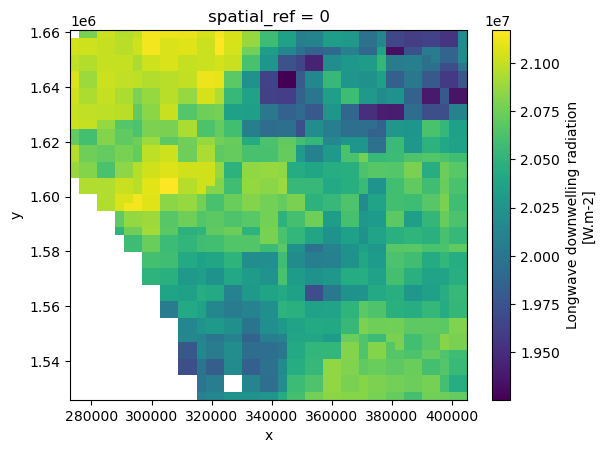

In [13]:
dst_rad.daily_radiation.plot()

### Creating a .tif file from the dataset

In [14]:
write_daily_radiation(dst_rad, date_rad)

### Preparing daily radidation files for the entire date range

In [15]:
prepare_daily_radiation(min_date_str, max_date_str, roi_path)

25-10-17 15:03:04 :: INFO :: File /home/paul-rohel/Bureau/timeseries/et-dataset/notebooks/MSG_data/MSG_2023-01-01/NETCDF4_LSASAF_MSG_DIDSSF_MSG-Disk_202301010000.nc already exists. Skip download.
25-10-17 15:03:04 :: INFO :: File /home/paul-rohel/Bureau/timeseries/et-dataset/notebooks/MSG_data/MSG_2023-01-01/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202212312345.nc already exists. Skip download.
25-10-17 15:03:04 :: INFO :: File /home/paul-rohel/Bureau/timeseries/et-dataset/notebooks/MSG_data/MSG_2023-01-01/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202301010000.nc already exists. Skip download.
25-10-17 15:03:04 :: INFO :: File /home/paul-rohel/Bureau/timeseries/et-dataset/notebooks/MSG_data/MSG_2023-01-01/NETCDF4_LSASAF_MSG_MDSSFTD_MSG-Disk_202301010015.nc already exists. Skip download.
25-10-17 15:03:04 :: INFO :: File /home/paul-rohel/Bureau/timeseries/et-dataset/notebooks/MSG_data/MSG_2023-01-01/NETCDF4_LSASAF_MSG_DSLF_MSG-Disk_202212312330.nc already exists. Skip download.
25-10-17 15:03:04 :

# ET Single Date

### Downloading ERA5-Land "Total Evaporation" product for the date range

In [17]:
date_list_et = download_et(min_date_str, max_date_str)

25-10-17 15:14:06 :: INFO :: File /home/paul-rohel/Bureau/timeseries/et-dataset/notebooks/ERA5_data/download_era5land_2023-01-01.zip already exits. Skip download.


2025-10-17 15:14:08,256 INFO Request ID is b354c281-95ea-4b0f-986a-87765bc9bcda
25-10-17 15:14:08 :: INFO :: Request ID is b354c281-95ea-4b0f-986a-87765bc9bcda
2025-10-17 15:14:47,796 INFO status has been updated to successful
25-10-17 15:14:47 :: INFO :: status has been updated to successful
25-10-17 15:14:48 :: INFO :: Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2025-10-17/4a5fee93ae99b0648df631e9b27bb6af.zip


In [19]:
date_et = date_list_et[1]


### Reading the content of the .zip directory as dataset

In [20]:
dst_et = read_et(date_et, grid)

In [21]:
dst_et

<xarray.Dataset> Size: 24kB
Dimensions:      (y: 45, x: 44)
Coordinates:
  * y            (y) float64 360B 1.527e+06 1.53e+06 ... 1.656e+06 1.659e+06
  * x            (x) float64 352B 2.745e+05 2.775e+05 ... 4.005e+05 4.035e+05
    spatial_ref  int64 8B 0
Data variables:
    et           (y, x) float32 8kB nan nan nan nan ... 0.1001 0.09369 0.08749
    flags        (y, x) int64 16kB 1 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0
Attributes:
    vis_date:  2023-01-02
    vis_time:  00:00:00

### Plotting the spatial distribution of evaporation over the ROI

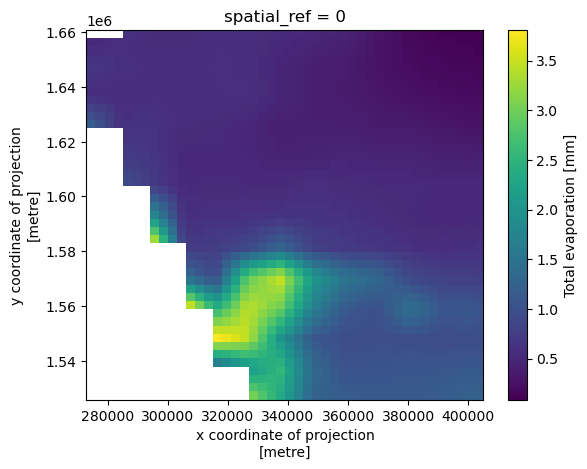

In [22]:
dst_et.et.plot()

### Creating a .tif file from the dataset

In [23]:
write_et_single_date(dst_et, date_et)

### Preparing et single date files for the entire date range

In [24]:
prepare_et_single_date(min_date_str, max_date_str, roi_path)

25-10-17 15:16:13 :: INFO :: File /home/paul-rohel/Bureau/timeseries/et-dataset/notebooks/ERA5_data/download_era5land_2023-01-01.zip already exits. Skip download.
25-10-17 15:16:13 :: INFO :: File /home/paul-rohel/Bureau/timeseries/et-dataset/notebooks/ERA5_data/download_era5land_2023-01-02.zip already exits. Skip download.
